In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

master = pd.read_csv("../data/cleaned/master_dataset.csv")

In [2]:
master["revenue"].sum()

np.float64(16643731.299999999)

In [3]:
master["order_id"].nunique()

99441

In [5]:
master["customer_unique_id"].nunique()

96096

In [6]:
master.groupby("order_id")["revenue"].sum().mean()

np.float64(167.372927665651)

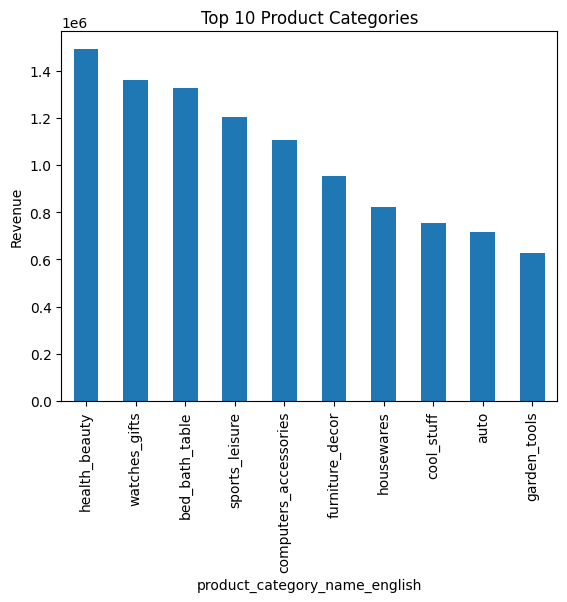

In [7]:
top_categories = (
    master.groupby("product_category_name_english")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_categories.plot(kind="bar")
plt.title("Top 10 Product Categories")
plt.ylabel("Revenue")
plt.show()

In [8]:
master["order_purchase_timestamp"] = pd.to_datetime(
    master["order_purchase_timestamp"]
)

In [9]:
master["year_month"] = (
    master["order_purchase_timestamp"]
    .dt.to_period("M")
)

In [10]:
monthly_revenue = (
    master.groupby("year_month")["revenue"]
    .sum()
)

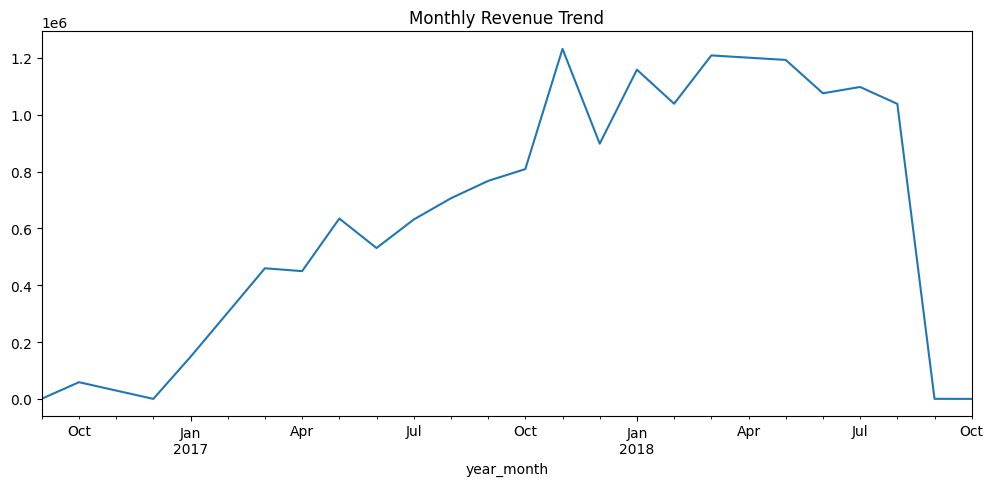

In [11]:
monthly_revenue.plot(figsize=(12,5))
plt.title("Monthly Revenue Trend")
plt.show()

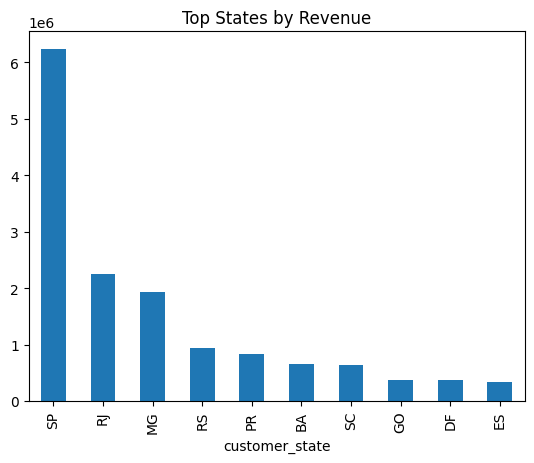

In [12]:
state_revenue = (
    master.groupby("customer_state")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

state_revenue.plot(kind="bar")
plt.title("Top States by Revenue")
plt.show()

In [13]:
master["review_score"].value_counts().sort_index()

review_score
1.0    15428
2.0     4162
3.0     9894
4.0    22319
5.0    66343
Name: count, dtype: int64

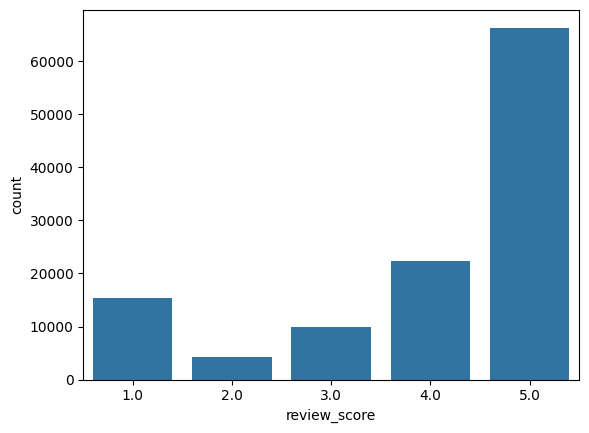

In [14]:
sns.countplot(
    x="review_score",
    data=master
)
plt.show()

In [15]:
master["delivery_days"].describe()

count    115722.000000
mean         12.022589
std           9.454922
min           0.000000
25%           6.000000
50%          10.000000
75%          15.000000
max         209.000000
Name: delivery_days, dtype: float64

In [16]:
(
    master["late_delivery"]
    .value_counts(normalize=True)
    * 100
)

late_delivery
False    93.655523
True      6.344477
Name: proportion, dtype: float64

In [17]:
master["payment_type"].value_counts()

payment_type
credit_card    87776
boleto         23190
voucher         6465
debit_card      1706
not_defined        3
Name: count, dtype: int64